# K-MEANS analysis (*Hartigan-Wong* clustering algorithm)

In [1]:
# Load my data
mydata <- read.csv("standardized_correlations.csv", sep = ";", header = TRUE, stringsAsFactors = FALSE)

In [2]:
mydata

Participant,corr_Duration_ImpactSpeed,corr_Duration_Amplitude,corr_ImpactSpeed_Amplitude
<int>,<dbl>,<dbl>,<dbl>
10,-0.37250571,0.49748561,0.6097775
11,0.19122648,0.78723532,0.8264278
12,0.41177393,0.77475809,1.3916665
13,0.09864760,0.55993440,1.1052822
14,-0.47996274,0.30317671,0.5201889
16,-0.38070308,0.40065589,0.7000302
17,-0.08486769,0.35188186,0.9515232
18,0.33675924,1.13935733,0.7955847
19,-0.35693426,-0.02259906,1.1138974


In [3]:
OUT_DIR  <- "kmeans_outputs_R"
if (!dir.exists(OUT_DIR)) dir.create(OUT_DIR, recursive = TRUE)

# Parameters

In [4]:

PARTICIPANT_COL <- "Participant"
FEATURE_COLS <- c(
  "corr_Duration_ImpactSpeed",
  "corr_Duration_Amplitude",
  "corr_ImpactSpeed_Amplitude"
)

K_STAT <- 3
ITER_MAX_STAT <- 10
SET_SEED <- 0

SORT_BY_PARTICIPANT <- FALSE

# t-SNE parameters
TSNE_DIMS <- 2
TSNE_PERPLEXITY <- 5      # For ~33 samples, 5 is safe. Must be < (n-1)/3
TSNE_MAX_ITER <- 1000

# Plot options
POINT_SIZE <- 3
LABEL_SIZE <- 6
SAVE_WIDTH <- 8
SAVE_HEIGHT <- 7
SAVE_DPI <- 300




In [5]:
install.packages("Rtsne")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [6]:
install.packages("ggplot2")

also installing the dependencies ‘S7’, ‘scales’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [7]:
install.packages("ggrepel")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [8]:
library(stats)
library(Rtsne)
library(ggplot2)
library(ggrepel)

In [9]:
required_cols <- c(PARTICIPANT_COL, FEATURE_COLS)
missing <- setdiff(required_cols, colnames(mydata))
if (length(missing) > 0) stop(paste("Missing columns:", paste(missing, collapse = ", ")))

if (SORT_BY_PARTICIPANT) {
  mydata <- mydata[order(mydata[[PARTICIPANT_COL]]), ]
}

Participant <- mydata[[PARTICIPANT_COL]]

# Feature matrix
X <- as.matrix(mydata[, FEATURE_COLS])
storage.mode(X) <- "double"

#t-SNE Perplexity Safety Check
n <- nrow(X)
if (TSNE_PERPLEXITY >= (n - 1) / 3) {
  stop(sprintf("Perplexity too high for n=%d. Choose perplexity < (n-1)/3 = %.2f",
               n, (n - 1) / 3))
}

cat("[INFO] Data loaded. n =", n, "| p =", ncol(X), "\n")
cat("[INFO] First K rows used as init centers for k-means:\n")
print(mydata[1:K_STAT, c(PARTICIPANT_COL, FEATURE_COLS)])

[INFO] Data loaded. n = 33 | p = 3 
[INFO] First K rows used as init centers for k-means:
  Participant corr_Duration_ImpactSpeed corr_Duration_Amplitude
1          10                -0.3725057               0.4974856
2          11                 0.1912265               0.7872353
3          12                 0.4117739               0.7747581
  corr_ImpactSpeed_Amplitude
1                  0.6097775
2                  0.8264278
3                  1.3916665


In [10]:

init_centers <- X[1:K_STAT, , drop = FALSE]

set.seed(SET_SEED)
km <- kmeans(
  X,
  centers   = init_centers,       
  iter.max  = ITER_MAX_STAT,     
  algorithm = "Hartigan-Wong"
)

clusters <- km$cluster  # 1..K

# --- SWAP CLUSTER 2 AND 3 TO MATCH Table 1 data where the individual r values are ranked in ascending order of correlation between Strike Duration and Impact Speed ---
# --- because CLUSTER 2 participants in Table 1 correspond to kmeans() output CLUSTER 3, and CLUSTER 3 participants in Table 1 correspond to kmeans() output CLUSTER 2 ---

clusters_new <- clusters
clusters_new[clusters == 2] <- 3
clusters_new[clusters == 3] <- 2
clusters <- clusters_new
# ------------------------------------------------

# Save assignments
df_assign <- data.frame(Subject = Participant, Cluster = clusters)
df_assign <- df_assign[order(df_assign$Cluster, df_assign$Subject), ]
write.table(
  df_assign,
  file = file.path(OUT_DIR, sprintf("assignments_K%d.csv", K_STAT)),
  sep = ";", row.names = FALSE, col.names = TRUE, quote = FALSE
)

# Save cluster lists
split_subjects <- split(df_assign$Subject, df_assign$Cluster)
df_counts <- data.frame(
  Cluster  = as.integer(names(split_subjects)),
  N        = as.integer(sapply(split_subjects, length)),
  Subjects = I(unname(split_subjects))
)
write.table(
  df_counts,
  file = file.path(OUT_DIR, sprintf("counts_K%d.csv", K_STAT)),
  sep = ";", row.names = FALSE, col.names = TRUE, quote = FALSE
)

cat("\n===== KMEANS RESULT =====\n")
for (k in 1:K_STAT) {
  subs <- split_subjects[[as.character(k)]]
  cat(sprintf("Cluster %d: n=%d -> %s\n", k, length(subs), paste(subs, collapse = ", ")))
}


===== KMEANS RESULT =====
Cluster 1: n=11 -> 10, 14, 16, 19, 20, 27, 29, 37, 41, 44, 50
Cluster 2: n=11 -> 13, 17, 21, 26, 30, 32, 33, 38, 42, 45, 46
Cluster 3: n=11 -> 11, 12, 18, 24, 25, 31, 35, 36, 39, 40, 43


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”



[INFO] Saved outputs to: kmeans_outputs_R 
[INFO] Elbow method saved as: kmeans_outputs_R/Elbow_method_plot.png 


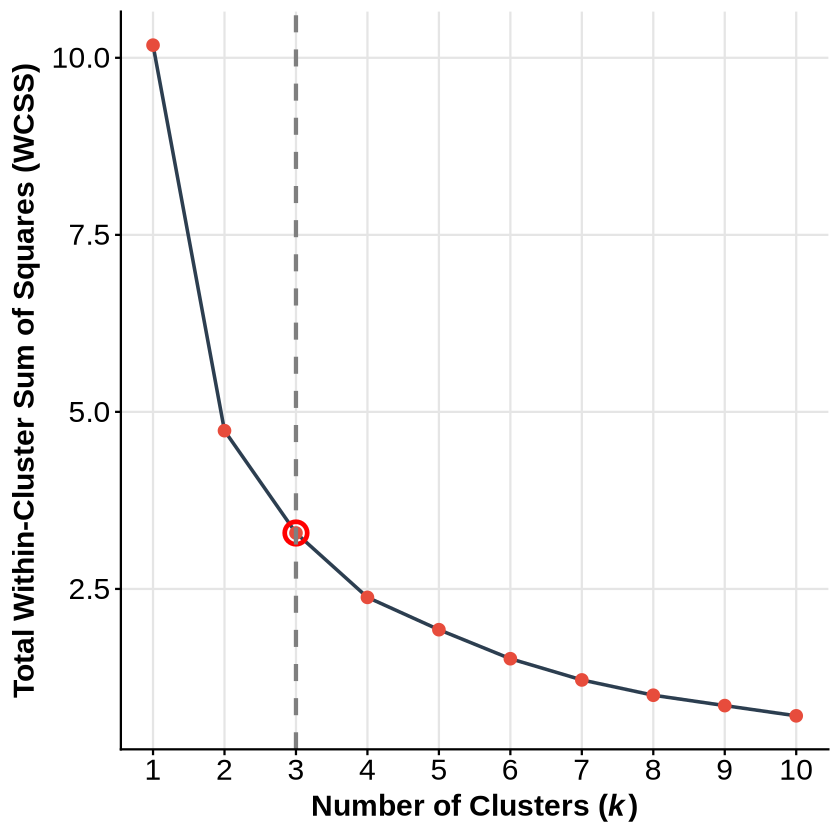

In [11]:
library(ggplot2)

# 1. Calculate WCSS for k = 1 to 10
set.seed(123) # For reproducibility
k_values <- 1:10
wcss_values <- sapply(k_values, function(k) {
  kmeans(X, centers = k, nstart = 25)$tot.withinss
})

# 2. Create a data frame for plotting
elbow_data <- data.frame(k = k_values, WCSS = wcss_values)

# 3. Generate the ggplot
elbow_method <- ggplot(elbow_data, aes(x = k, y = WCSS)) +
  geom_line(color = "#2c3e50", size = 1) +
  geom_point(color = "#e74c3c", size = 3) +
  # Highlight k=3 with a specific point style
  geom_point(data = subset(elbow_data, k == 3), color = "red", size = 5, shape = 1, stroke = 2) +
  geom_vline(xintercept = 3, linetype = "dashed", color = "gray50", linewidth = 1.2) +
  scale_x_continuous(breaks = 1:10) +
  labs(
        x = bquote(bold("Number of Clusters (" * bolditalic(k) * ")")),
    y =  bquote(bold("Total Within-Cluster Sum of Squares (WCSS)"))
  ) +
  theme_classic(base_size = 14) +
  theme(
        panel.grid.major = element_line(color = "gray90"),
     axis.title = element_text(size = 18, face = "bold"),
  axis.text = element_text(size = 18),
  legend.title =  element_blank(),
  legend.text = element_text(size = 16)
  )

print(elbow_method)

# Save plot
ggsave(
  filename = file.path(OUT_DIR, sprintf("Elbow_method_plot.png")),
  plot = elbow_method,
  width = SAVE_WIDTH,
  height = SAVE_HEIGHT,
  dpi = SAVE_DPI
)

cat("\n[INFO] Saved outputs to:", OUT_DIR, "\n")
cat("[INFO] Elbow method saved as:",
    file.path(OUT_DIR, sprintf("Elbow_method_plot.png")), "\n")

In [12]:
# Computes the gain in explained variance from each additional cluster
# 1. Run k-means for k=1 through k=4
set.seed(123)
km1 <- kmeans(X, centers = 1, nstart = 25)
km2 <- kmeans(X, centers = 2, nstart = 25)
km3 <- kmeans(X, centers = 3, nstart = 25)
km4 <- kmeans(X, centers = 4, nstart = 25)
km5 <- kmeans(X, centers = 5, nstart = 25)

# 2. Calculate the "Drop" (Reduction in WCSS)
drop_1_to_2 <- km1$tot.withinss - km2$tot.withinss
drop_2_to_3 <- km2$tot.withinss - km3$tot.withinss
drop_3_to_4 <- km3$tot.withinss - km4$tot.withinss
drop_4_to_5 <- km4$tot.withinss - km5$tot.withinss

# 3. Calculate % Improvement relative to Total Variance
pct_1_to_2 <- (drop_1_to_2 / km1$tot.withinss) * 100
pct_2_to_3 <- (drop_2_to_3 / km1$tot.withinss) * 100
pct_3_to_4 <- (drop_3_to_4 / km1$tot.withinss) * 100
pct_4_to_5 <- (drop_4_to_5 / km1$tot.withinss) * 100

# Print the results
cat("Improvement 1->2:", round(pct_1_to_2, 1), "%\n")
cat("Improvement 2->3:", round(pct_2_to_3, 1), "%\n")
cat("Improvement 3->4:", round(pct_3_to_4, 1), "%\n")
cat("Improvement 4->5:", round(pct_4_to_5, 1), "%\n")

Improvement 1->2: 53.5 %
Improvement 2->3: 14.2 %
Improvement 3->4: 8.9 %
Improvement 4->5: 4.5 %


# t-SNE plot for visualization

In [13]:

set.seed(SET_SEED)
tsne_res <- Rtsne(
  X,
  dims = TSNE_DIMS,
  perplexity = TSNE_PERPLEXITY,
  verbose = TRUE,
  max_iter = TSNE_MAX_ITER,
  check_duplicates = FALSE
)

df_tsne <- data.frame(
  Subject = Participant,
  Cluster = factor(clusters),
  TSNE1 = tsne_res$Y[, 1],
  TSNE2 = tsne_res$Y[, 2]
)

# Calculate the average t-SNE coordinates for each cluster center
tsne_centroids <- aggregate(cbind(TSNE1, TSNE2) ~ Cluster, 
                            data = df_tsne, 
                            FUN = mean)

# Save t-SNE coordinates
write.table(
  df_tsne,
  file = file.path(OUT_DIR, sprintf("tsne_coords_K%d.csv", K_STAT)),
  sep = ";", row.names = FALSE, col.names = TRUE, quote = FALSE
)


Performing PCA
Read the 33 x 3 data matrix successfully!
OpenMP is working. 1 threads.
Using no_dims = 2, perplexity = 5.000000, and theta = 0.500000
Computing input similarities...
Building tree...
Done in 0.00 seconds (sparsity = 0.547291)!
Learning embedding...
Iteration 50: error is 62.032841 (50 iterations in 0.00 seconds)
Iteration 100: error is 57.869436 (50 iterations in 0.00 seconds)
Iteration 150: error is 57.200649 (50 iterations in 0.00 seconds)
Iteration 200: error is 60.408236 (50 iterations in 0.00 seconds)
Iteration 250: error is 60.876101 (50 iterations in 0.00 seconds)
Iteration 300: error is 1.813414 (50 iterations in 0.00 seconds)
Iteration 350: error is 1.259041 (50 iterations in 0.00 seconds)
Iteration 400: error is 1.079878 (50 iterations in 0.00 seconds)
Iteration 450: error is 0.716516 (50 iterations in 0.00 seconds)
Iteration 500: error is 0.437321 (50 iterations in 0.00 seconds)
Iteration 550: error is 0.289102 (50 iterations in 0.00 seconds)
Iteration 600: e

In [14]:
df_tsne

Subject,Cluster,TSNE1,TSNE2
<int>,<fct>,<dbl>,<dbl>
10,1,46.1379982,53.044100
11,3,-34.1462447,-27.401273
12,3,-70.4505042,-13.588633
13,2,-1.9506372,-34.626847
14,1,57.3747087,69.388130
16,1,54.4915445,52.687376
17,2,16.4676201,-12.989719
18,3,-56.1658503,-59.610396
19,1,78.8242983,28.148692



[INFO] Saved outputs to: kmeans_outputs_R 
[INFO] t-SNE figure saved as: kmeans_outputs_R/tSNE_clusters_K_labeled.png 


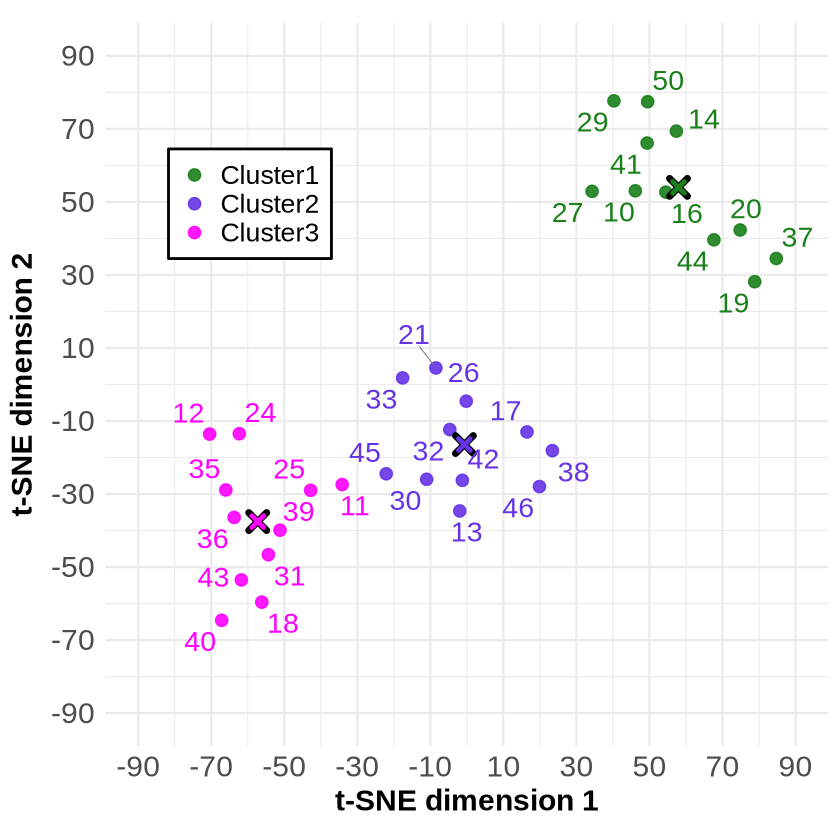

In [15]:
# My custom color palette
my_colors <- c(
    "1" = "#1A801A", # Cluster 1: dark green
    "2" = "#6633E6", # Cluster 2: purple
    "3" = "#FF00FF"  # Cluster 3: magenta
)

p_tsne <- ggplot(df_tsne, aes(x = TSNE1, y = TSNE2, color = Cluster)) +
  geom_point(size = POINT_SIZE, alpha = 0.9) +

# --- ADDS CENTROIDS ---
  # Layer A: The "Border" (A slightly thicker black cross)
  geom_point(data = tsne_centroids, 
             aes(x = TSNE1, y = TSNE2), 
             color = "black",    # The border color
             shape = 4,          # Cross shape
             size = 3,           # Slightly larger than the colored cross
             stroke = 3,         # Thick stroke for the border effect
             show.legend = FALSE) +
  
  # Layer B: The "Fill" (The colored cross on top)
  geom_point(data = tsne_centroids, 
             aes(x = TSNE1, y = TSNE2, color = Cluster), 
             shape = 4,          # Cross shape
             size = 2,           # Slightly smaller
             stroke = 2,         # Standard thickness
             show.legend = FALSE) +
  # ----------------------------------------

# Apply the custom colors here
  scale_color_manual(values = my_colors, labels = c("Cluster1", "Cluster2", "Cluster3")) +

# Force 1:1 aspect ratio and similar scales
  coord_fixed(ratio = 1) + 
  scale_x_continuous(breaks = seq(-90, 90, by = 20), limits = c(-90, 90)) +
  scale_y_continuous(breaks = seq(-90, 90, by = 20), limits = c(-90, 90)) +

  geom_text_repel(
    aes(label = Participant),
    size = LABEL_SIZE,
    max.overlaps = Inf,      # show all labels
    box.padding = 0.4,
    point.padding = 0.3,
    segment.color = "grey50",
    segment.size = 0.3,
    show.legend = FALSE
  ) +
  theme_minimal(base_size = 14) +
  labs(
 #   title = "t-SNE visualization of K-means clusters",
  #  subtitle = paste("K =", K_STAT,
  #                   "| kmeans = Hartigan-Wong",
   #                  "| perplexity =", TSNE_PERPLEXITY),
    x = "t-SNE dimension 1",
    y = "t-SNE dimension 2",
    color = "Cluster"
  ) +
  theme(
    plot.title = element_text(face = "bold"),

      # 2. Make the legend float
    # c(0.9, 0.2) puts it in the bottom right. Adjust these values (0 to 1) to move it.
    legend.position = c(0.2, 0.75), 
    legend.background = element_rect(fill = "white", color = "black", linewidth = 0.8),
     
  axis.title = element_text(size = 18, face = "bold"),
  axis.text = element_text(size = 18),
  legend.title =  element_blank(),
  legend.text = element_text(size = 16)
          
  )

print(p_tsne)

# Save plot
ggsave(
  filename = file.path(OUT_DIR, sprintf("tSNE_clusters_K%d_labeled.png", K_STAT)),
  plot = p_tsne,
  width = SAVE_WIDTH,
  height = SAVE_HEIGHT,
  dpi = SAVE_DPI
)

cat("\n[INFO] Saved outputs to:", OUT_DIR, "\n")
cat("[INFO] t-SNE figure saved as:",
    file.path(OUT_DIR, sprintf("tSNE_clusters_K_labeled.png")), "\n")

In [16]:
install.packages("patchwork")


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [17]:
library(patchwork)

In [28]:
# Combine the plots
# The '+' signs place them side-by-side
# Combine with a spacer in the middle
# We use 'plot_spacer()' and assign it a relative width
combined_plot <- elbow_method + plot_spacer() + p_tsne + 
  plot_layout(widths = c(1, 0.05, 1)) &   # 0.1 is the width of the gap
  theme(aspect.ratio = 1)

# Save using ggsave or cowplot
ggsave("combined_figure_elbow&t_sne.png", combined_plot, width = 14, height = 7, units = "in")

ggsave("600dpi_combined_figure_elbow&t_sne.png", combined_plot, width = 14, height = 7, units = "in", dpi = 600)

ggsave("1200dpi_combined_figure_elbow&t_sne.png", combined_plot, width = 14, height = 7, units = "in", dpi = 1200)

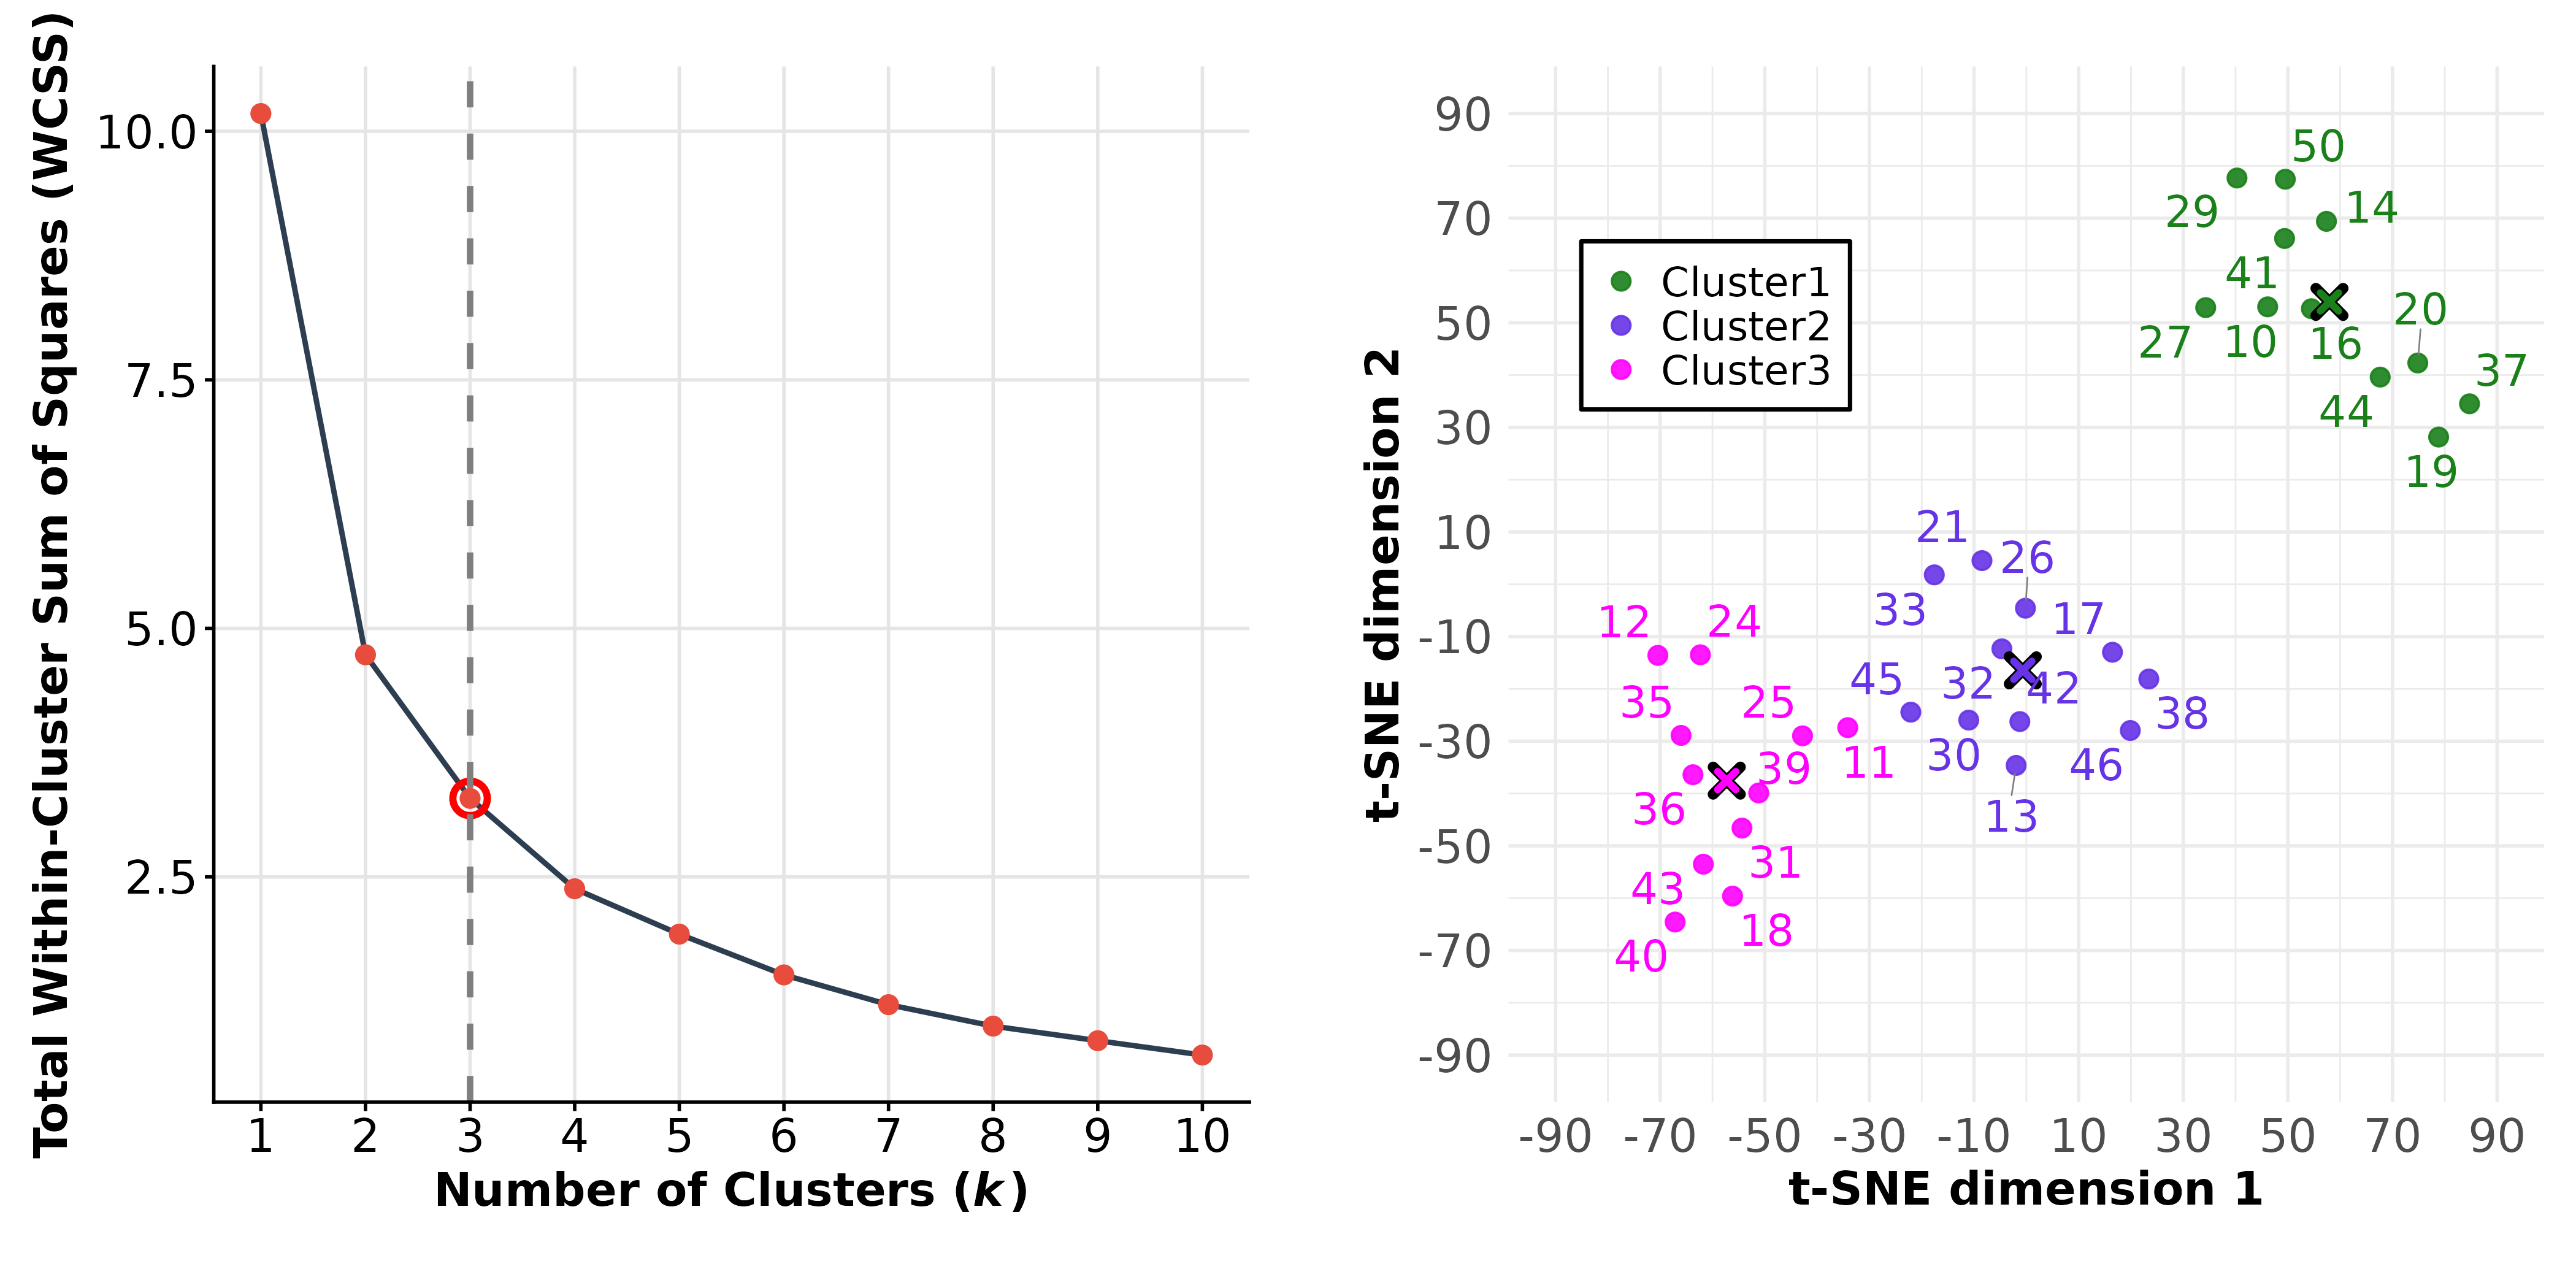

In [19]:
library(IRdisplay)
display_png(file = "combined_figure_elbow&t_sne.png")

In [27]:
# Save with a scale factor to make elements appear larger relative to the plot
ggsave(
  filename = "combined_figure_elbow_tsne_v4.tif", 
  plot = combined_plot, 
  device = "tiff",
  width = 174, 
  height = 87, 
  units = "mm", 
  dpi = 600,
  scale = 2,      # Decreasing scale (< 1) makes text/points look LARGER
  compression = "lzw"
)


ggsave("600dpi_combined_figure_elbow_tsne.eps", 
       combined_plot, 
       device = cairo_ps, 
       width = 174, 
       height = 87, 
       units = "mm",
       dpi = 600,
       scale = 2)


ggsave("1200dpi_combined_figure_elbow_tsne.eps", 
       combined_plot, 
       device = cairo_ps, 
       width = 174, 
       height = 87, 
       units = "mm",
       dpi = 1200,
       scale = 2)

# Within-Cluster Sum of Squares (WCSS) analysis

In [21]:
# km$withinss : WSS per cluster (within-cluster sum of squares)
# km$tot.withinss : sum of WSS values (global WCSS)
# km$totss : total sum of squares (around the global mean)
# km$betweenss : between-cluster sum of squares

wcss_per_cluster <- km$withinss
wcss_total <- km$tot.withinss
tss_total <- km$totss
bss_total <- km$betweenss

# Variance explained (R² analogue for k-means)
variance_explained <- bss_total / tss_total

cat("\n===== WITHIN-CLUSTER SUM OF SQUARES (WCSS) ANALYSIS =====\n")
cat(sprintf("Total SS (TSS)        = %.6f\n", tss_total))
cat(sprintf("Between SS (BSS)      = %.6f\n", bss_total))
cat(sprintf("Total Within SS (WCSS)= %.6f\n", wcss_total))
cat(sprintf("Variance explained    = %.3f (BSS/TSS)\n", variance_explained))

# Detailed table per cluster
df_wcss <- data.frame(
  Cluster = 1:K_STAT,
  N = as.integer(table(clusters)),
  WithinSS = as.numeric(wcss_per_cluster)
)

# Add proportions 
df_wcss$WithinSS_Percent <- 100 * df_wcss$WithinSS / wcss_total

# Export CSV
write.table(
  df_wcss,
  file = file.path(OUT_DIR, sprintf("wcss_analysis_K%d.csv", K_STAT)),
  sep = ";", row.names = FALSE, col.names = TRUE, quote = FALSE
)

# Figure: WSS per cluster
png(filename = file.path(OUT_DIR, sprintf("wcss_by_cluster_K%d.png", K_STAT)),
    width = 900, height = 600)

barplot(
  height = df_wcss$WithinSS,
  names.arg = paste0("C", df_wcss$Cluster),
  xlab = "Cluster",
  ylab = "Within-cluster sum of squares (WithinSS)",
  main = sprintf(
    "WCSS by cluster (K=%d) | Total WCSS=%.2f | Explained=%.2f%%",
    K_STAT, wcss_total, 100 * variance_explained
  )
)
grid()
dev.off()

cat("\n[INFO] WCSS table saved -> ",
    file.path(OUT_DIR, sprintf("wcss_analysis_K%d.csv", K_STAT)), "\n")
cat("[INFO] WCSS figure saved -> ",
    file.path(OUT_DIR, sprintf("wcss_by_cluster_K%d.png", K_STAT)), "\n")




===== WITHIN-CLUSTER SUM OF SQUARES (WCSS) ANALYSIS =====
Total SS (TSS)        = 10.178523
Between SS (BSS)      = 6.888877
Total Within SS (WCSS)= 3.289645
Variance explained    = 0.677 (BSS/TSS)


pdf 
  2


[INFO] WCSS table saved ->  kmeans_outputs_R/wcss_analysis_K3.csv 
[INFO] WCSS figure saved ->  kmeans_outputs_R/wcss_by_cluster_K3.png 


## Computation of the Calinski-Harabasz index

In [22]:
# The Calinski-Harabasz Formula
ch_index <- (km$betweenss / (k - 1)) / (km$tot.withinss / (n - k))

print(ch_index)

[1] 31.41164


In [23]:
#alternative computation using the fpc package

install.packages("fpc")

also installing the dependencies ‘modeltools’, ‘DEoptimR’, ‘mclust’, ‘flexmix’, ‘prabclus’, ‘diptest’, ‘robustbase’, ‘kernlab’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [24]:
library(fpc)
stats <- cluster.stats(dist(X), km$cluster, silhouette = TRUE)
print(stats$ch)  # Returns the Calinski-Harabasz index

[1] 31.41164


In [25]:
# Define the values
f_val <- 30.37
df1 <- 2        # clusters - 1
df2 <- 30       # participants - clusters

# Calculate p-value (area in the upper tail)
p_val <- pf(f_val, df1, df2, lower.tail = FALSE)

# Print result in scientific notation
formatC(p_val, format = "e", digits = 2)

[1] "6.16e-08"

In [26]:
# Shows 10 decimal places to ensure the small value is visible
formatC(p_val, format = "f", digits = 10)

[1] "0.0000000616"